In [50]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
sys.path.insert(0,'../g3algo/')
import iterativecombination as ic
from center_binned_stats import center_binned_stats as cbs
binvalues = [11,11.15,11.3,11.45,11.6,11.75,12.,12.25,12.5,12.75,12.95,13.3,14.75]

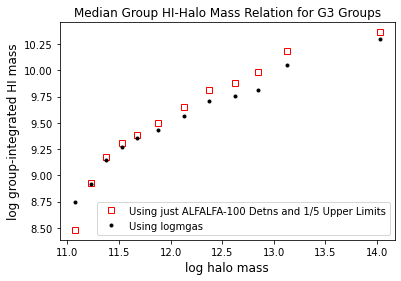

In [60]:
%matplotlib inline
plt.figure()


ecodata = pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")
ecodata = ecodata[(ecodata.g3grpcz_l<7000)&(ecodata.g3grpcz_l>3000)&(ecodata.absrmag<-17.33)]
ecodata = ecodata[(ecodata.mhidet_a100>0)|(ecodata.mhilim_a100>0)]
realmhi = 10**ecodata.logmgas/1.4 # just for testing
ecodata.loc[:,'realmhi'] = realmhi
mhigrpreal = ic.get_int_mass(np.log10(ecodata.realmhi.to_numpy()), ecodata.g3grp_l.to_numpy())
ecodata.loc[:,'mhigrpreal'] = mhigrpreal

mhisim = ecodata.mhidet_a100 + (1/5.)*ecodata.mhilim_a100
ecodata.loc[:,'mhisim'] = mhisim
mhigrpsim = ic.get_int_mass(np.log10(ecodata.mhisim.to_numpy()), ecodata.g3grp_l.to_numpy())
ecodata.loc[:,'mhigrpsim'] = mhigrpsim


ecodata = ecodata[ecodata.g3fc_l>0]
medianmhigrpsim,bincenters,_,_=cbs(ecodata.g3logmh_l.to_numpy(),ecodata.mhigrpsim.to_numpy(),'median',bins=binvalues)
plt.plot(bincenters,medianmhigrpsim,'s',markerfacecolor='None',markeredgecolor='red',label=r'Using just ALFALFA-100 Detns and 1/5 Upper Limits')
medianmhigrpreal,bincenters,_,_=cbs(ecodata.g3logmh_l.to_numpy(),ecodata.mhigrpreal.to_numpy(),'median',bins=binvalues)
plt.plot(bincenters,medianmhigrpreal,'k.',label=r'Using logmgas')


plt.legend(loc='lower right',fontsize=10)
plt.ylabel("log group-integrated HI mass",fontsize=12)
plt.xlabel('log halo mass',fontsize=12)
plt.title("Median Group HI-Halo Mass Relation for G3 Groups")
plt.show()

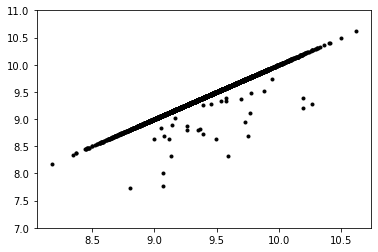

In [59]:
ecodata = pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")
ecodata = ecodata[(ecodata.g3grpcz_l<7000)&(ecodata.g3grpcz_l>3000)&(ecodata.absrmag<-17.33)]
ecodata = ecodata[(ecodata.mhidet_a100>0)&(ecodata.confused==0)]
plt.plot(np.log10(ecodata.mhidet_a100+0.*ecodata.mhilim_a100),ecodata.logmgas_a100-np.log10(1.4),'k.')
plt.ylim(7,11)
plt.show()

### What about high M_bary/L_r galaxies?

In [117]:
resolvedata = pd.read_csv("../resolve_and_eco/RESOLVEdata_G3catalog_luminosity.csv")
resolvedata.loc[:,'logmbary'] = np.log10(10**resolvedata.logmstar+10**resolvedata.logmgas)

In [118]:
# baryonic mass limit for RESOLVE-A 9.4, 9.1 for RES-B
czlim = (resolvedata.g3grpcz_l>4500)&(resolvedata.g3grpcz_l<7000)
Asemsel = (resolvedata.f_a==1)&(resolvedata.logmbary>9.4)&czlim
Bsemsel = (resolvedata.f_b==1)&(resolvedata.logmbary>9.1)&czlim
barycomp = Asemsel | Bsemsel
resolvedata=resolvedata[(resolvedata.g3logmh_l<11.2) & barycomp]

In [119]:
np.log10(10**resolvedata.logmgas.median() / 1.4)

9.200270322131761

In [120]:
resolvedata = pd.read_csv("../resolve_and_eco/RESOLVEdata_G3catalog_luminosity.csv")
resolvedata = resolvedata[(resolvedata.g3grpcz_l>4500)&(resolvedata.g3grpcz_l<7000)&(resolvedata.fl_insample==1)]

In [121]:
resolvedata=resolvedata[(resolvedata.g3logmh_l<11.2)]

In [122]:
np.log10(10**resolvedata.logmgas.median() / 1.4)

8.775090003871762

In [124]:
9.22 - 8.77

0.45000000000000107

## What about the 2 r200 aperture?

In [155]:
import foftools as fof
from scipy.spatial import cKDTree

In [168]:
ecodata = pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")
ecodata = ecodata[(ecodata.g3fc_l>0)&(ecodata.g3logmh_l<11.3)&(ecodata.g3logmh_l>0)]
# what is the typical distance between halos of mass 11.5?

In [169]:
rr = ecodata.g3grpcz_l.to_numpy()/70.
dtor = np.pi/180.
theta = np.pi/2. - ecodata.g3grpdedeg_l.to_numpy()*dtor
phi = ecodata.g3grpradeg_l.to_numpy()*dtor
zmpc = rr*np.cos(theta)
xmpc = rr*np.sin(theta)*np.cos(phi)
ympc = rr*np.sin(theta)*np.sin(phi)
coords = np.array([xmpc,ympc,zmpc]).T

In [170]:
kdt = cKDTree(coords)
nndist, nnind = kdt.query(coords,k=2)
nndist=nndist[:,1] # ignore self match
nnind=nnind[:,1] # ignore self match

In [171]:
radeg = ecodata.g3grpradeg_l.to_numpy()
dedeg = ecodata.g3grpdedeg_l.to_numpy()
cz = ecodata.g3grpcz_l.to_numpy()
radeg_nn = radeg[nnind]
dedeg_nn = dedeg[nnind]
cz_nn = cz[nnind]

In [172]:
onskysep = (1/70.)*(cz+cz_nn)*np.sin(fof.angular_separation(radeg,dedeg,radeg_nn,dedeg_nn)) #Mpc

0.3528340078721912


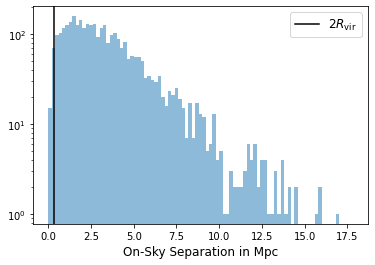

In [180]:
plt.figure()
plt.hist(onskysep,log=True,bins=np.arange(0,18,0.2),alpha=0.5)
tworvir = 2 * ( 3*10**(11.5) / (4*np.pi*337*0.3*1.36e11) )**(1/3)
print(tworvir)
plt.xlabel("On-Sky Separation in Mpc",fontsize=12)
plt.axvline(tworvir,color='k',label=r'$2R_{\rm vir}$')
plt.legend(loc='upper right',fontsize=12)
plt.show()

In [174]:
(np.sum(onskysep<tworvir))/len(onskysep)

0.02145110410094637

In [176]:
print(np.median(onskysep))

2.798031988399532


In [175]:
ix = np.argmax(onskysep)
cz[ix],cz_nn[ix]

(4524.5, 4491.599999999999)

# O19 simulation


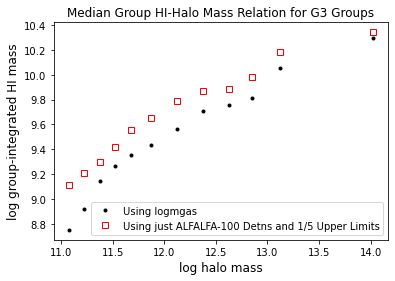

In [66]:
%matplotlib inline
plt.figure()


ecodata = pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")
ecodata = ecodata[(ecodata.g3grpcz_l<7000)&(ecodata.g3grpcz_l>3000)&(ecodata.absrmag<-17.33)]
ecodata = ecodata[(ecodata.mhidet_a100>0)|(ecodata.mhilim_a100>0)]
realmhi = 10**ecodata.logmgas/1.4 # just for testing
ecodata.loc[:,'realmhi'] = realmhi
mhigrpreal = ic.get_int_mass(np.log10(ecodata.realmhi.to_numpy()), ecodata.g3grp_l.to_numpy())
ecodata.loc[:,'mhigrpreal'] = mhigrpreal

mhisim = ecodata.mhidet_a100 + 1# + (1/5.)*ecodata.mhilim_a100
ecodata.loc[:,'mhisim'] = mhisim
mhigrpsim = ic.get_int_mass(np.log10(ecodata.mhisim.to_numpy()), ecodata.g3grp_l.to_numpy())
ecodata.loc[:,'mhigrpsim'] = mhigrpsim


ecodata = ecodata[(ecodata.g3fc_l>0)]
medianmhigrpreal,bincenters,_,_=cbs(ecodata.g3logmh_l.to_numpy(),ecodata.mhigrpreal.to_numpy(),'median',bins=binvalues)
plt.plot(bincenters,medianmhigrpreal,'k.',label=r'Using logmgas')
ecodata = ecodata[(ecodata.mhigrpsim>0)]
medianmhigrpsim,bincenters,_,_=cbs(ecodata.g3logmh_l.to_numpy(),ecodata.mhigrpsim.to_numpy(),'median',bins=binvalues)
plt.plot(bincenters,medianmhigrpsim,'s',markerfacecolor='None',markeredgecolor='red',label=r'Using just ALFALFA-100 Detns and 1/5 Upper Limits')



plt.legend(loc='lower right',fontsize=10)
plt.ylabel("log group-integrated HI mass",fontsize=12)
plt.xlabel('log halo mass',fontsize=12)
plt.title("Median Group HI-Halo Mass Relation for G3 Groups")
plt.show()

In [67]:
medianmhigrpsim - medianmhigrpreal

array([0.36451184, 0.29093234, 0.14873719, 0.15055098, 0.19806001,
       0.21623646, 0.22666197, 0.16256015, 0.12901995, 0.16492295,
       0.13465821, 0.04592252])